# OCT B-scan preprocessing

This notebook constructs the preprocessing pipeline that maps a raw OCT B-scan to a fixed input suitable for a classifier. Notebook 1 established that the three imaging devices produce images of different size, aspect ratio, and appearance, and that image size alone is predictive of the class. The objective of preprocessing is to remove the properties that identify the device while preserving the retinal tissue, so that a model trained on one device transfers to devices it has not seen.

Each preprocessing component is presented as an independent decision. The notebook illustrates the effect of each component on one scan from every device. The selection of the final combination is not fixed by hand. It is determined empirically on the unseen OCTDL set by the search in experiments/run_preprocessing.py, and the results of that search are reported at the end of this notebook.

## Two preprocessing regimes

The components described below combine into one of two regimes.

**Full-frame regime.** The entire image is retained and resized to the target frame. This approach is simple and robust because it makes no assumption about the location of the retina. Its weakness is that a large fraction of the input is background, which reduces the resolution available to the tissue.

**Cropped regime.** The image is reduced to the retinal band before resizing. This approach allocates the full resolution to the retina, at the cost of depending on a reliable band detector.

Neither regime is assumed to be superior. Both are evaluated on the unseen set, and the comparison is reported in the preprocessing search.

## Setup

The following cell imports the preprocessing functions from the ocular.preprocess module and loads one representative scan from each device. It performs no preprocessing decision and only prepares the building blocks.

In [1]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ocular import config
from ocular.preprocess import (
    load_gray,
    blacken_padding,
    background_fill,
    retina_rows,
    crop_to_retina,
    retina_center,
    curvature_correct,
    stretch,
    squish,
    letterbox,
    width_crop,
    preprocess,
)

random.seed(config.SEED)
%matplotlib inline

example_path = {
    "Kermany": sorted((config.TRAINING_DIR / "NORMAL").glob("*.jpeg"))[0],
    "OCTDL": sorted((config.DATA_DIR / "raw" / "octdl_dl" / "OCTDL" / "NO").glob("*"))[0],
    "Clinic": sorted((config.DATA_DIR / "raw" / "bscans").glob("NORMAL*.png"))[0],
}
examples = {name: load_gray(p) for name, p in example_path.items()}

## 1. Padding removal

**Rationale.** The training images were rotated in order to improve robustness, and the rotation leaves bright padding in the corners of the frame where it exposed empty area. This padding is brighter than the retina, so a brightness based detector would lock onto it rather than the tissue. The primary purpose of removing the padding is therefore to protect the retina detector that runs in the next step.

**Method.** Two strategies are available. The first sets the padding to black. The second sets it to the dark background level of the same image, which avoids introducing a hard edge.

**Selection.** Black is sufficient in the cropped regime because the padding is discarded during cropping. Background fill is preferred in the full-frame regime, where the padding is retained, because a uniform dark region is interpreted as background rather than as an artificial bright object.

**On the residual signature.** The fill removes the bright padding but not the rotation itself, since the shape of the filled corners still reflects the angle by which the image was turned, and this is acceptable for two related reasons. In the cropped regime the corners are cut away and nothing remains, whereas in the full-frame regime the corners stay but every class was rotated in the same way, so the rotation is not associated with any particular class and cannot help the model tell the classes apart.

The figure below shows a training scan that contains bright padding together with the two removal strategies.

In the code, the padding is located by `padding_mask`, which takes the near-white pixels and keeps only the connected regions that touch an edge of the frame, so the bright corner padding is separated from the equally bright retinal pigment epithelium in the interior. `blacken_padding` then sets those pixels to zero for the cropped regime, while `background_fill` sets them to a low percentile of the image, the dark background level, for the full-frame regime where the corners are kept.

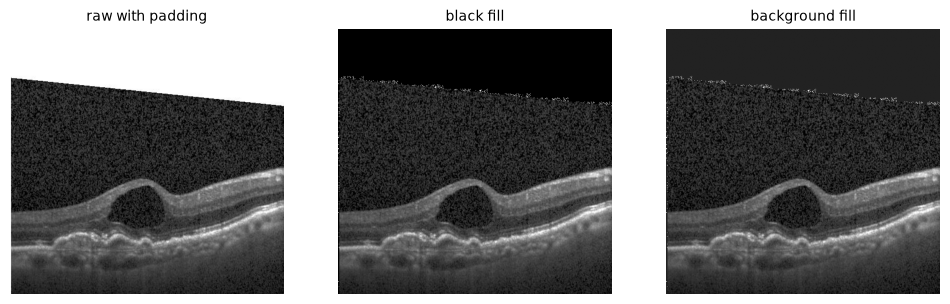

In [2]:
# select a training scan that shows the bright rotation padding
padded = examples["Kermany"]
for cls in config.CLASSES:
    for p in sorted((config.TRAINING_DIR / cls).glob("*.jpeg"))[:300]:
        g = load_gray(p)
        if (g >= 248).mean() > 0.15:
            padded = g
            break
    else:
        continue
    break

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(padded, cmap="gray")
axes[0].set_title("raw with padding", fontsize=10)
axes[1].imshow(blacken_padding(padded), cmap="gray")
axes[1].set_title("black fill", fontsize=10)
axes[2].imshow(background_fill(padded), cmap="gray")
axes[2].set_title("background fill", fontsize=10)
for a in axes:
    a.axis("off")
plt.show()

## 2. Retinal band cropping

**Rationale.** The retina occupies a thin horizontal band within a frame that is otherwise background. When the full height is retained, most of the input carries no diagnostic signal and the effective resolution of the tissue is low. Cropping to the band allocates the entire vertical resolution to the retina.

**How the detector works.** The band is found from the horizontal brightness of the image rather than from any learned model. The mean brightness of every row is computed and lightly smoothed, which produces a one dimensional profile that is high where the row passes through tissue and low where the row is background. A threshold is placed a fixed fraction of the way between the background level and the brightest row, and the band is taken to be the longest continuous run of rows that sit above this threshold. Choosing the longest run rather than every bright row makes the detector robust to thin bright artefacts such as edge lines, which are bright but short. The image is then cropped to this run together with a small margin above and below.

**Trade-off.** The detector depends on the retina being the brightest sustained structure in the image, therefore the cropped regime is evaluated against the full-frame regime rather than assumed to be superior.

The first figure below shows the detector on one scan. The left panel marks the detected top and bottom of the band, the middle panel shows the row brightness profile with the threshold and the selected band, and the right panel shows the final crop. The second figure applies the same crop to one scan from every device, which shows that the detector locates the band on machines it was not tuned for.

The two functions that implement this are `retina_rows`, which returns the top and bottom rows of the band, and `crop_to_retina`, which cuts the image to that band with a small margin above and below. Both read brightness alone and fit no model, which is why the crop transfers to devices it was never tuned on.

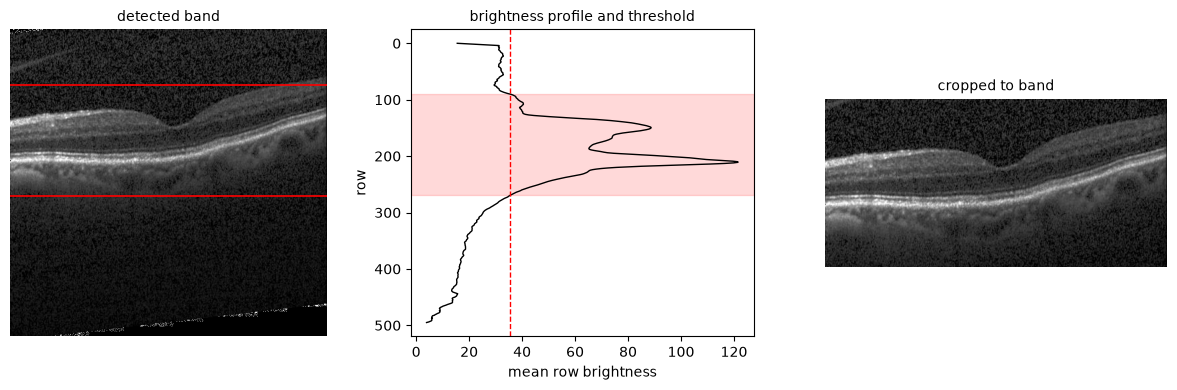

In [3]:
# illustrate the band detector on one training scan
raw = examples["Kermany"]
g = blacken_padding(raw)
row = g.mean(1)
k = max(3, len(row) // 60)
smooth = np.convolve(row, np.ones(k) / k, mode="same")
lo, hi = int(0.04 * len(row)), int(0.96 * len(row))
base = np.percentile(smooth, 20)
thr = base + 0.18 * (smooth[lo:hi].max() - base)
top, bottom = retina_rows(g)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(g, cmap="gray")
axes[0].axhline(top, color="red", lw=1.2)
axes[0].axhline(bottom, color="red", lw=1.2)
axes[0].set_title("detected band", fontsize=10)
axes[0].axis("off")

idx = np.arange(len(smooth))
axes[1].plot(smooth, idx, color="black", lw=1)
axes[1].axvline(thr, color="red", ls="--", lw=1)
axes[1].axhspan(top, bottom, color="red", alpha=0.15)
axes[1].invert_yaxis()
axes[1].set_xlabel("mean row brightness")
axes[1].set_ylabel("row")
axes[1].set_title("brightness profile and threshold", fontsize=10)

axes[2].imshow(crop_to_retina(raw), cmap="gray")
axes[2].set_title("cropped to band", fontsize=10)
axes[2].axis("off")

plt.tight_layout()
plt.show()

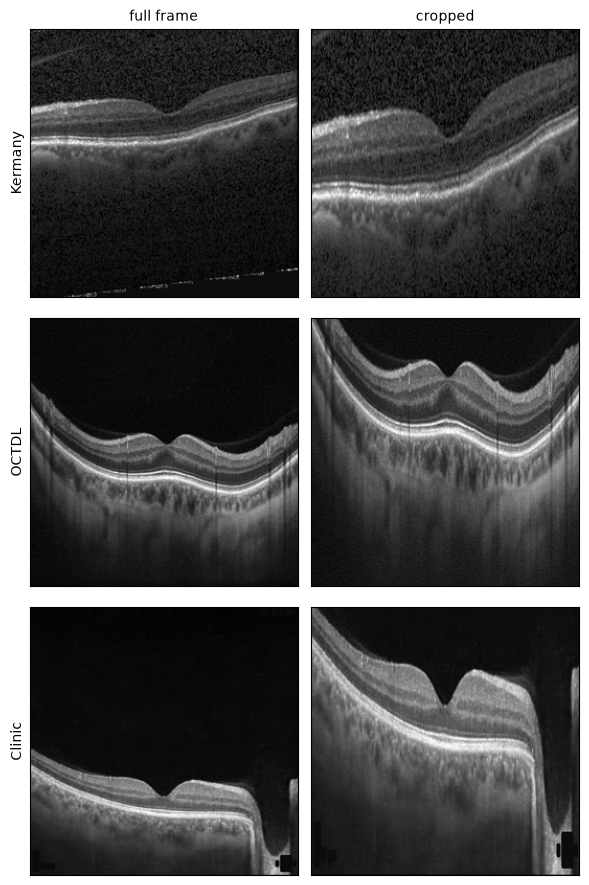

In [4]:
# the same crop applied to one scan from every device
fig, axes = plt.subplots(3, 2, figsize=(6, 9))
for r, (name, g) in enumerate(examples.items()):
    axes[r, 0].imshow(squish(background_fill(g), 256, 256), cmap="gray")
    axes[r, 0].set_ylabel(name, fontsize=10)
    axes[r, 1].imshow(squish(crop_to_retina(g), 256, 256), cmap="gray")
    for col in (0, 1):
        axes[r, col].set_xticks([])
        axes[r, col].set_yticks([])
axes[0, 0].set_title("full frame", fontsize=10)
axes[0, 1].set_title("cropped", fontsize=10)
plt.subplots_adjust(wspace=0.04, hspace=0.08, left=0.06, right=0.98, top=0.96, bottom=0.02)
plt.show()

## 3. Curvature correction

**Rationale.** The retina is curved rather than flat. Even after cropping, a portion of the vertical extent is occupied by the arc of the band rather than by tissue at a given depth. Flattening the retina recovers this vertical space and increases the resolution available to small features such as drusen.

**Method.** The vertical centre of the band is estimated for each column, a smooth curve is fitted across the columns, and each column is shifted so that the band becomes horizontal.

**Interaction with rotation.** Flattening aligns every scan to the horizontal, which removes the rotation that the training set applied deliberately for robustness. To retain that robustness, rotation is reintroduced as a training augmentation rather than baked into the cache.

The figure below shows the cropped band before and after correction.

The two functions are `retina_center`, which estimates the vertical centre of the band for each column as a brightness-weighted mean row, and `curvature_correct`, which fits a smooth low-degree polynomial across those column centres and shifts each column vertically so the band becomes flat. The regions left exposed by the shift are filled with the background level.

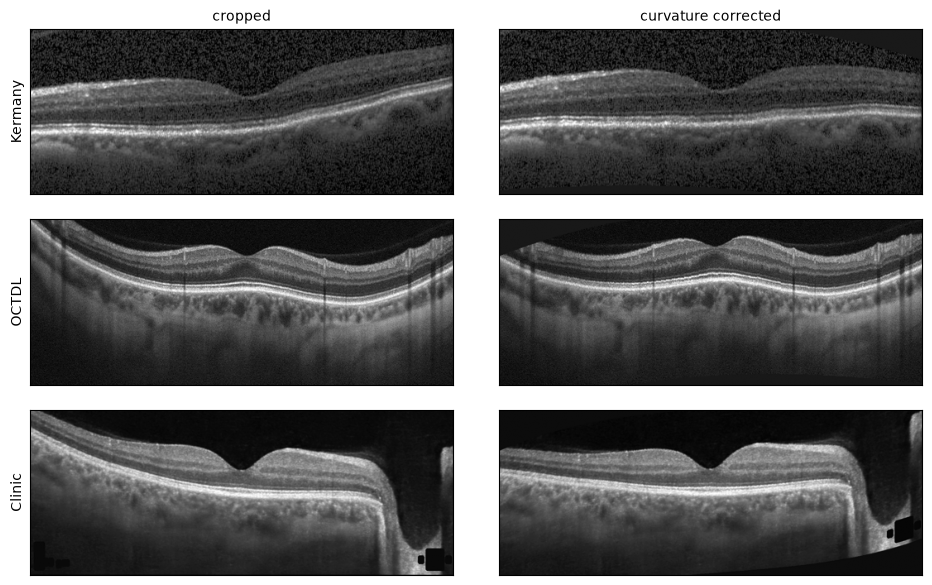

In [5]:
# curvature correction shown at a common wide frame so the panels align
fig, axes = plt.subplots(3, 2, figsize=(10, 6))
for r, (name, g) in enumerate(examples.items()):
    c = crop_to_retina(g)
    axes[r, 0].imshow(squish(c, 512, 200), cmap="gray")
    axes[r, 0].set_ylabel(name, fontsize=10)
    axes[r, 1].imshow(squish(curvature_correct(c), 512, 200), cmap="gray")
    for col in (0, 1):
        axes[r, col].set_xticks([])
        axes[r, col].set_yticks([])
axes[0, 0].set_title("cropped", fontsize=10)
axes[0, 1].set_title("curvature corrected", fontsize=10)
plt.subplots_adjust(wspace=0.04, hspace=0.15, left=0.06, right=0.98, top=0.94, bottom=0.03)
plt.show()

## 4. Width fitting

**Rationale.** The retina is wider than it is tall, so mapping it into a narrow or square frame requires a choice about how the width is handled. The three strategies differ in what they preserve and what they distort.

**Squish.** The width is rescaled to fit the frame. The full retina is retained but compressed horizontally, which can attenuate small features.

**Letterbox.** The aspect ratio is preserved and the remaining area is padded. No distortion is introduced, however the extent of the padding encodes the original aspect ratio and can therefore leak the device identity.

**Width crop.** The lateral edges are removed to reach the target aspect ratio. The native scale is preserved but peripheral tissue may be discarded.

Because the three strategies trade different properties, they are compared directly at the square frame, where the difference between them is largest. The figure below shows the three results side by side.

Each strategy is a single function. `squish` rescales the width to the frame, `letterbox` preserves the aspect ratio and pads the remaining area, and `width_crop` trims the lateral edges to reach the target ratio.

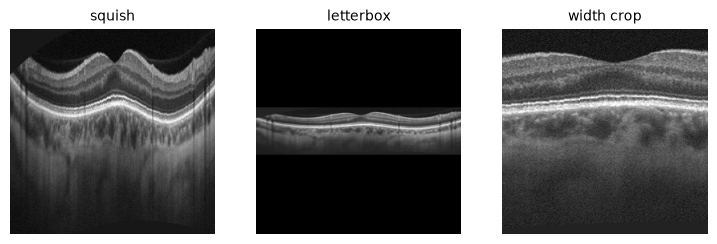

In [6]:
c = curvature_correct(crop_to_retina(examples["OCTDL"]))
fig, axes = plt.subplots(1, 3, figsize=(9, 4))
axes[0].imshow(squish(c, 256, 256), cmap="gray")
axes[0].set_title("squish", fontsize=10)
axes[1].imshow(letterbox(c, 256, 256), cmap="gray")
axes[1].set_title("letterbox", fontsize=10)
axes[2].imshow(width_crop(c, 256, 256), cmap="gray")
axes[2].set_title("width crop", fontsize=10)
for a in axes:
    a.axis("off")
plt.show()

## 5. Input aspect ratio

**Rationale.** The shape of the input frame determines how much horizontal detail is preserved. A wide retina mapped to a square frame loses lateral detail, whereas a wide frame retains it. Because the small drusen that drive the hardest cases are defined by fine horizontal structure, the aspect ratio is expected to affect the drusen class in particular.

**Options.** Three aspect ratios are evaluated. These are one to one, one and a half to one, and three to one. A wider frame preserves more detail but requires more memory, so the choice is a trade-off between accuracy and cost.

The figure below shows one scan placed into the three input frames, drawn at their true relative widths so that the difference in shape is visible directly.

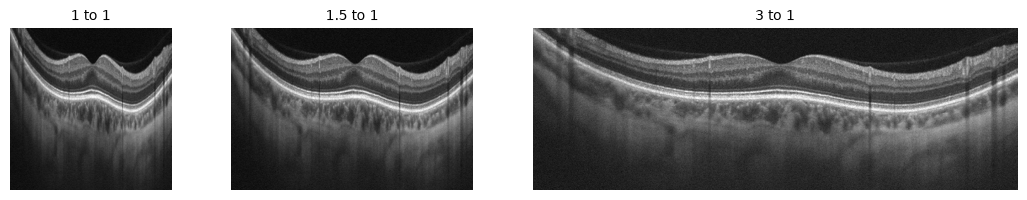

In [7]:
# one scan at the three input frames, drawn at their true relative widths
c = crop_to_retina(examples["OCTDL"])
shapes = {"1 to 1": (256, 256), "1.5 to 1": (384, 256), "3 to 1": (768, 256)}
fig, axes = plt.subplots(1, 3, figsize=(13, 3),
                         gridspec_kw={"width_ratios": [w / h for w, h in shapes.values()]})
for ax, (name, wh) in zip(axes, shapes.items()):
    ax.imshow(squish(c, wh[0], wh[1]), cmap="gray")
    ax.set_title(name, fontsize=10)
    ax.axis("off")
plt.show()

## Rotation and contrast normalisation

Two further operations complete the pipeline.

**Rotation.** The training set was released with rotation already applied in order to improve robustness. This rotation is retained rather than removed, except where curvature correction requires a flat retina, in which case the rotation is reintroduced as a training augmentation.

**Contrast.** Each image is rescaled to a common intensity range using a percentile stretch, so that a bright device and a dim device produce comparable images. This removes a further cue that would otherwise identify the acquiring device.

The contrast step is `stretch`, which clips each image to a low and a high percentile and rescales to a common range, so a bright device and a dim device produce comparable images.

The single entry point that runs the whole pipeline is `preprocess`. It applies the steps in order, namely padding neutralisation, an optional crop to the retinal band and curvature correction, a contrast stretch and a width fit, and returns the final single-channel frame in the range zero to one. Each keyword flag of `preprocess` selects one of the decisions described above.

## Combining the components

None of the components above is fixed in this notebook by hand. Each represents a decision, and the objective is to determine which combination transfers best to a device the model has not seen. This search is the preprocessing search and comprises eleven configurations evaluated with a ResNet50 backbone. Configurations are ranked on the unseen OCTDL set, with drusen recall as the primary criterion and overall accuracy as the secondary criterion. The configurations are defined in experiments/run_preprocessing.py, which writes one row of results per configuration to experiments/results/preprocessing_results.csv. The section that follows reads that file and reports the outcome of the search.

## Preprocessing search results

Before any full training run, the eleven preprocessing configurations are screened on a class-balanced subsample of the training set, three thousand images per class, with a ResNet50 backbone. This screen is built to rank the configurations against one another and not to measure final quality, so the numbers below sit lower than the full-data model reported later and should be read only as a comparison between rows. The table is read directly from experiments/results/preprocessing_results.csv and sorted by drusen recall on the unseen OCTDL set, which is the primary ranking criterion. The two families in the table are the full-frame configurations, which keep the whole scan, and the cropped configurations, which isolate the retinal band before fitting. The findings that follow read from this same table.

The screen was produced by running

    python experiments/run_preprocessing.py

which walks all eleven configurations, trains a ResNet50 on the balanced subsample for a few epochs each, scores every one on the unseen OCTDL set and on the clinic set, and appends one row per configuration to `experiments/results/preprocessing_results.csv`. That single command wrote the eleven rows the table below reads, so the numbers shown are exactly what it produced.

In [8]:
search = pd.read_csv(config.ROOT / "experiments" / "results" / "preprocessing_results.csv")

frame = search["width"].astype(str) + "x" + search["height"].astype(str)
view = pd.DataFrame({
    "crop": search["crop"],
    "curvature": search["curvature"],
    "fit": search["fit"],
    "frame": frame,
    "octdl_macro_f1": search["octdl_macro_f1"].round(3),
    "octdl_drusen_recall": search["octdl_recall_DRUSEN"].round(3),
    "clinic_acc": search["clinic_acc"].round(3),
})
view = view.sort_values("octdl_drusen_recall", ascending=False).reset_index(drop=True)
view

,crop,curvature,fit,frame,octdl_macro_f1,octdl_drusen_recall,clinic_acc
0,True,True,squish,256x256,0.894,0.682,0.649
1,True,True,squish,384x256,0.891,0.672,0.649
2,False,True,squish,448x448,0.872,0.620,0.676
3,True,True,squish,768x256,0.878,0.609,0.541
4,True,False,squish,768x256,0.867,0.589,0.432
5,True,False,squish,256x256,0.874,0.557,0.622
6,True,False,squish,384x256,0.870,0.536,0.622
7,True,False,width_crop,256x256,0.850,0.536,0.486
8,False,True,squish,544x352,0.848,0.526,0.568
9,True,False,letterbox,256x256,0.837,0.490,0.568


### Curvature correction is the main lever

**Finding.** Correcting the retinal curvature is the single change that moves the drusen class the most. Holding the crop, the fit method and the frame fixed, adding curvature correction raises OCTDL drusen recall by roughly twelve to fourteen points at the narrow frames, from 0.56 to 0.68 at the square frame and from 0.54 to 0.67 at the one and a half to one frame. The effect nearly vanishes at the widest frame, where recall rises by only two points.

**Why.** Curvature correction flattens the retina and returns vertical resolution to the band. Once that resolution is restored the square and near-square frames become the strongest, and the widest frame no longer holds an advantage. This reverses the earlier expectation that a wider frame is needed for drusen, because the benefit that width appeared to give was in fact the vertical resolution that curvature recovers directly. The left panel below shows drusen recall and the right panel shows macro-F1, in both cases grouped by frame width with and without curvature.

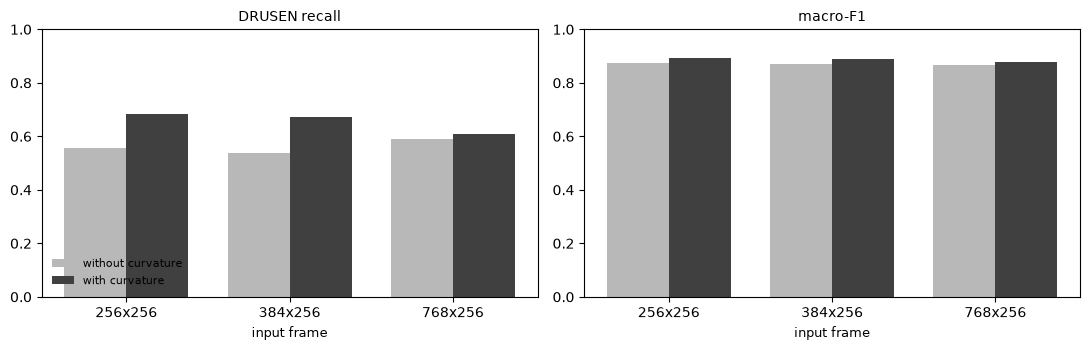

In [9]:
# controlled comparison, cropped and squished, curvature on versus off
sq = search[(search["crop"]) & (search["fit"] == "squish")]
frames = [256, 384, 768]
metrics = [("octdl_recall_DRUSEN", "DRUSEN recall"), ("octdl_macro_f1", "macro-F1")]

off = sq[~sq["curvature"]].set_index("width")
on = sq[sq["curvature"]].set_index("width")
x = np.arange(len(frames))
w = 0.38

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (col, label) in zip(axes, metrics):
    ax.bar(x - w / 2, [off.loc[f, col] for f in frames], w, label="without curvature", color="0.72")
    ax.bar(x + w / 2, [on.loc[f, col] for f in frames], w, label="with curvature", color="0.25")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{f}x256" for f in frames])
    ax.set_xlabel("input frame", fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1)
axes[0].legend(fontsize=8, frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

### Squish is the safest way to reach the frame

**Finding.** Once the frame width is fixed, the way the retina is fitted into it also matters. Comparing the three fit strategies at the square frame, squish reaches the highest drusen recall, width crop is close behind, and letterbox is clearly the weakest.

**Why.** Letterbox preserves the aspect ratio and pads the remaining area, and the amount of padding encodes the original aspect ratio of the device. The model can read that padding as a shortcut to the device identity rather than learning the pathology, which is the leakage described in the width fitting section above. Squish introduces horizontal compression but adds no such artefact, so it transfers more reliably to an unseen device.

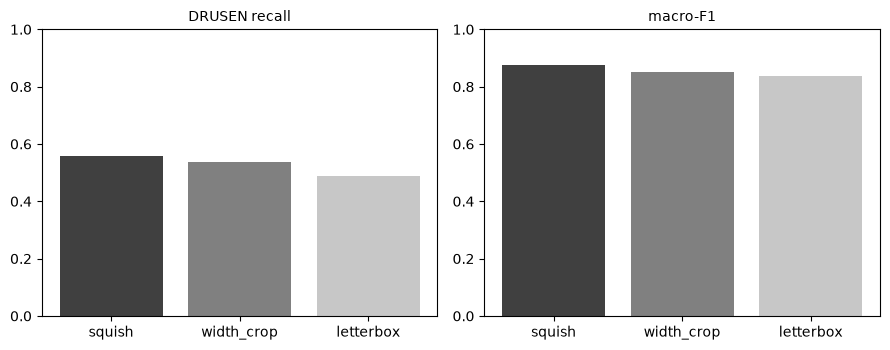

In [10]:
# fit strategies compared at the square frame, cropped and without curvature
fit_rows = search[(search["crop"]) & (~search["curvature"])
                & (search["width"] == 256) & (search["height"] == 256)].set_index("fit")
order = ["squish", "width_crop", "letterbox"]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, (col, label) in zip(axes, metrics):
    ax.bar(order, [fit_rows.loc[m, col] for m in order], color=["0.25", "0.5", "0.78"])
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### Carried forward

**Outcome.** The strongest configuration is crop with curvature correction and squish, at the square frame and at the one and a half to one frame. These two frames are almost tied on drusen recall and both clear the full-frame configurations, which confirms that isolating the retinal band before fitting helps. As an illustration, the best full-frame configuration reaches a macro-F1 of 0.87 while the cropped square configuration reaches 0.89 at roughly a third of the pixels. Both winning frames are carried forward into the model phase, where the backbone is varied while the preprocessing is held fixed.

## Cache construction

Training a model under a given configuration requires the training set already preprocessed under that same configuration. Preprocessing every image on the fly at each epoch would repeat identical work many times, so the preprocessed set is materialised once and read back across epochs. This holds for every configuration evaluated during the search and for the configuration that is finally chosen. Images are stored as single channel unsigned 8-bit arrays at the configuration frame. During training they are converted to floating point, the single channel is repeated three times to match the input expected by pretrained backbones, and they may be downscaled further for a smaller model. A cache is rebuilt only when a model requires a frame larger than the stored one. The cell below demonstrates the pipeline on a small sample.

In [11]:
split = pd.read_csv(config.DATA_DIR / "split.csv")
label_id = {c: i for i, c in enumerate(config.CLASSES)}
demo = split.sample(8, random_state=config.SEED)
xs = np.stack([preprocess(config.TRAINING_DIR / c / f, 256, 256)
               for f, c in zip(demo["filename"], demo["class"])])
ys = np.array([label_id[c] for c in demo["class"]])
print("sample cache", xs.shape, "labels", ys.tolist())

sample cache (8, 256, 256) labels [3, 0, 0, 3, 2, 0, 1, 3]
